# Attack vs Normal Traffic Distribution in NSL-KDD and CICIDS2017
  

1. This notebook explores the distribution of attacks vs normal traffic in the NSL-KDD and CICIDS2017 datasets.

2. .We create both binary classification (Normal vs Attack) and multi-class classification (Attack Types) visualizations.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nicer
sns.set(style="whitegrid", palette="muted", font_scale=1.2)

## NSL-KDD Dataset

  Intially let's load the NSL-KDD data set and explore its structure for better understanding and create a Binary-column for Attack Vs Normal traffic

In [22]:

df = pd.read_csv("/content/drive/MyDrive/nsl-kdd/KDDTrain+.txt", header=None)



columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
    'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count',
    'serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','level'
]
df.columns = columns

mapping_attacks= {
    'neptune': 'DoS', 'smurf': 'DoS', 'back': 'DoS', 'teardrop': 'DoS', 'pod': 'DoS',
    'satan': 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe',
    'guess_passwd': 'R2L', 'ftp_write': 'R2L', 'imap': 'R2L', 'phf': 'R2L',
    'multihop': 'R2L', 'warezmaster': 'R2L', 'warezclient': 'R2L',
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'rootkit': 'U2R', 'perl': 'U2R',
    'normal': 'Normal'
}
df['category'] = df['outcome'].map(mapping_attacks).fillna('Other')

df['binary'] = df['category'].apply(lambda x: 'Normal' if x=='Normal' else 'Attack')

------------------------------------------------------------------------
## Documentation of the above code

 1. Intially we loaded train data to df, (header = None) specifies the first row is not a column name so that it will take or generate numbers as column

 2. we redefining the column name for the better understanding this will replace the corresponding numbers into column names making it feasible to undestand

 3. we are mapping the variety of attacks into categories in a dictionary form and creating a new column as category which will added to our dataframe. if any category isnt found in dictionary it fill as Other

 4. And we created and added another column to our dataframe as binary column which will give as either or style output as its attack or normal
 -----------------------------------------------------------------------

## Binary Classification: Normal vs Attack

Visualizing the distribution of normal vs attack traffic in the NSL-KDD dataset.

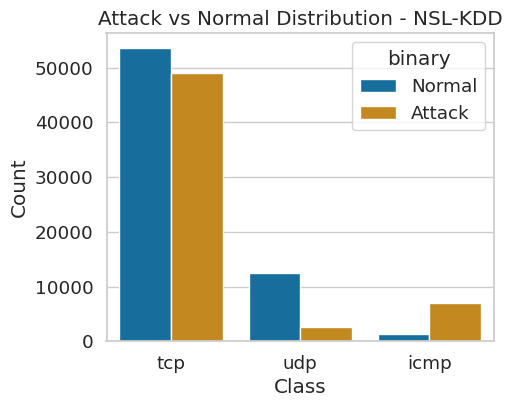

In [30]:
plt.figure(figsize=(5,4))
# using Seaborn’s countplot, which shows how many times each category appears.
sns.countplot(x='protocol_type', data=df, palette='colorblind', hue='binary', legend=True)
plt.title('Attack vs Normal Distribution - NSL-KDD')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

## Multi-Classification visualization

Here we are gonna visualize the top 10 attacks in these categories

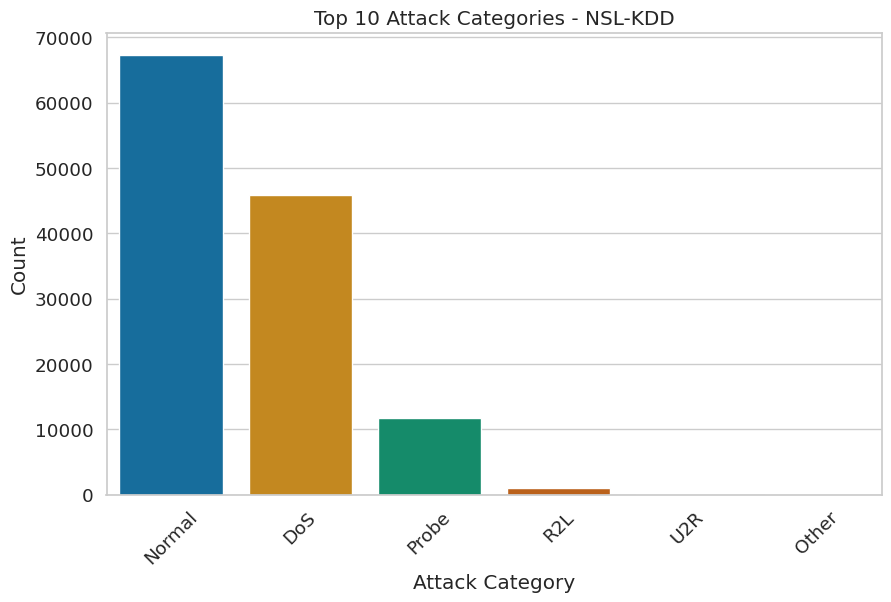

In [28]:
top_attacks = df['category'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_attacks.index, y=top_attacks.values, hue=top_attacks.index, dodge=False, palette='colorblind', legend=False)
plt.title('Top 10 Attack Categories - NSL-KDD')
plt.xlabel('Attack Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()